In [1]:
%load_ext autoreload
%autoreload 2
import cooler
import pandas as pd

res = 12800
# res = 12800

cool_nc18 = cooler.Cooler(f'./cools/nc1-8_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/{res}')
cool_nc14 = cooler.Cooler(f'./cools/nc14_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/{res}')
cool_s10 = cooler.Cooler(f'./cools/s10-12_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/{res}')

In [2]:
%load_ext autoreload
%autoreload
import scanpy as sc
import sys

sys.path.append('./code2')

from hic_zscore_functions import make_obs_exp_intra
from aux_functions import *
from plotting_functions import *

sc.settings.set_figure_params(dpi=80, color_map='coolwarm', frameon=True)
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({"axes.grid.axis" : 'both'})
plt.rcParams.update({"axes.grid" : True})

plt.rcParams.update({
    'axes.labelsize': 14,       # x and y labels' font size
    'xtick.labelsize': 8,      # x tick labels' font size
    'ytick.labelsize': 8,      # y tick labels' font size
    'axes.titlesize': 14,        # Axes title font size
    'patch.linewidth' : .35,
    'lines.linewidth' : .5,
    'legend.fontsize': 6,      # Legend font size
})
plt.rcParams['pdf.fonttype'] = 42

plt.rcParams.update({
    'axes.labelsize': 8,       # x and y labels' font size
    'xtick.labelsize': 6,      # x tick labels' font size
    'ytick.labelsize': 6,      # y tick labels' font size
    'axes.titlesize': 10,        # Axes title font size
    'patch.linewidth' : .35,
    'lines.linewidth' : .5,
    'xtick.major.pad' : 2,
    'ytick.major.pad' : 2,

})
plt.rcParams['axes.linewidth'] = .25
plt.rcParams['xtick.major.width'] = .25
plt.rcParams['ytick.major.width'] = .25
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['grid.linewidth'] = .25

plt.rcParams['axes.facecolor'] = 'none' # Or any suitable colour...
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'none'

plt.rcParams['axes.facecolor'] = 'none' # Or any suitable colour...
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'none'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from config import load_cses, load_loop_anchors
from config import rgb_to_cluster, cluster_to_rgb

all_cses = load_cses()
all_loop_anchors = load_loop_anchors()

In [4]:
nc14_boundaries = pd.read_csv('./annotations/nc14_1_1+1_2+2_1+2_2.boundaries_and_both_with_cluster_colors.scores=plain.bed',
                   sep = '\t', 
                              header=None
                  )

nc14_boundaries['cluster'] = nc14_boundaries[8].apply(rgb_to_cluster.get)

Mitotic GAF
Mitotic GAF


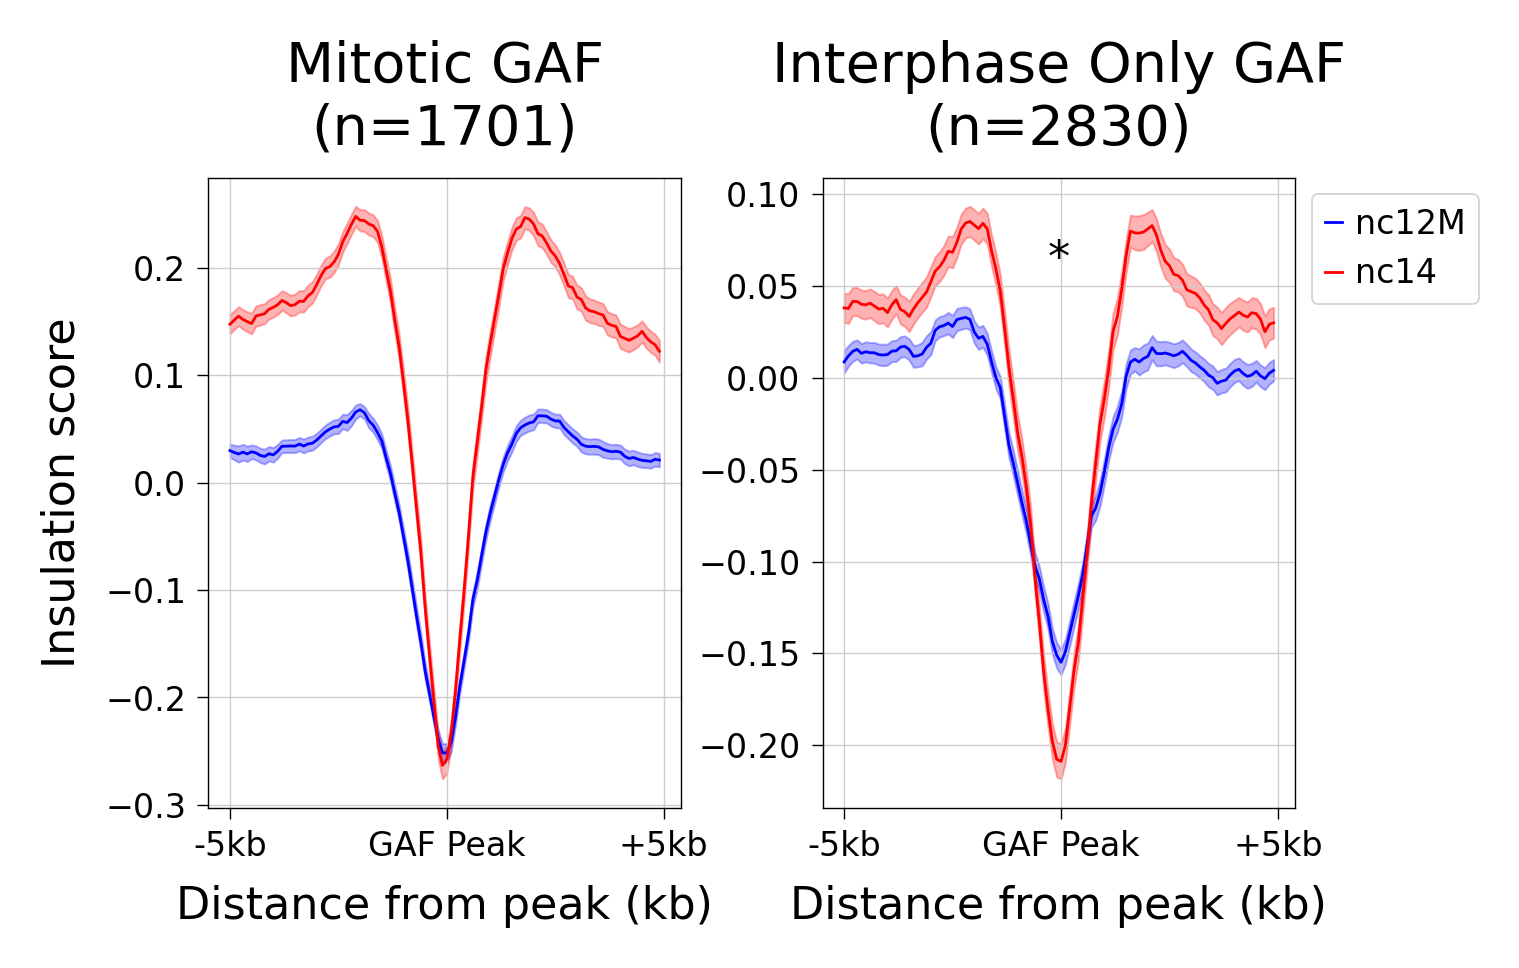

In [6]:
%autoreload 2
from insulation_at_mitotic_gaf_atac import mitotic_vs_interphase_insulation

parsed_chroms = add_chr_to_list(['2L', '2R', '3L', '3R', '4', 'X'])
interphase_gaf_peaks = pbt.BedTool('/Genomics/argo/users/gdolsten/pritlab/nc14/jupys/annotations/gaf_perturbation_effects/bellec/GSE180812_CHIP_GAF_interphase_merge_rep1_rep2_rep3_peaks_100_50_200.bed')
mitotic_gaf_peaks = pbt.BedTool('/Genomics/argo/users/gdolsten/pritlab/nc14/jupys/annotations/gaf_perturbation_effects/bellec/GSE180812_ChIP_GAF_mitosis_merge_rep1_rep2_peaks_100_50_200.bed')

interphase_gaf_peaks = interphase_gaf_peaks.filter(lambda x: x[0] in parsed_chroms).saveas()
mitotic_gaf_peaks = mitotic_gaf_peaks.filter(lambda x: x[0] in parsed_chroms).saveas()


mito_gaf_insulation, fig = mitotic_vs_interphase_insulation(
    {
        'Mitotic GAF' : mitotic_gaf_peaks,
        'Interphase Only GAF' : interphase_gaf_peaks.subtract(mitotic_gaf_peaks.slop(b=2000, genome='dm6'), A=True),
    }, 
    plot=True
);